In [3]:
import numpy as np # for matrix operations and fast math functions

import glob
import os as os # for operating system path manipulation

import scipy.signal as signal # for signal processing functions
from scipy.signal import butter, filtfilt, fftconvolve, get_window, resample
from scipy.signal.windows import hann
from scipy.special import erfc
from scipy import stats

import matplotlib.pyplot as plt # for plotting things
import IPython.display as ipd # displaying audio in the python notebook
from IPython.display import clear_output
from matplotlib.gridspec import GridSpec

import soundfile as sf # for loading and writing audio files
from pydub import AudioSegment
from pydub.utils import mediainfo
import subprocess
from scipy.io.wavfile import write
from scipy.io import wavfile

import sys
import os

# Get the absolute path of the library folder
lib_path = os.path.abspath("/Users/luna/Documents/Research/Codes/Pyrat2")
sys.path.append(lib_path)

import pyrat2 as pyrat

In [4]:
ir1 = '/Users/luna/Documents/Research/Chauvet/Fieldwork/2024/Ambi/ambiX_E1.wav'
ir2 = '/Users/luna/Documents/Research/Chauvet/Fieldwork/2024/Ambi/ambiX_E2.wav'

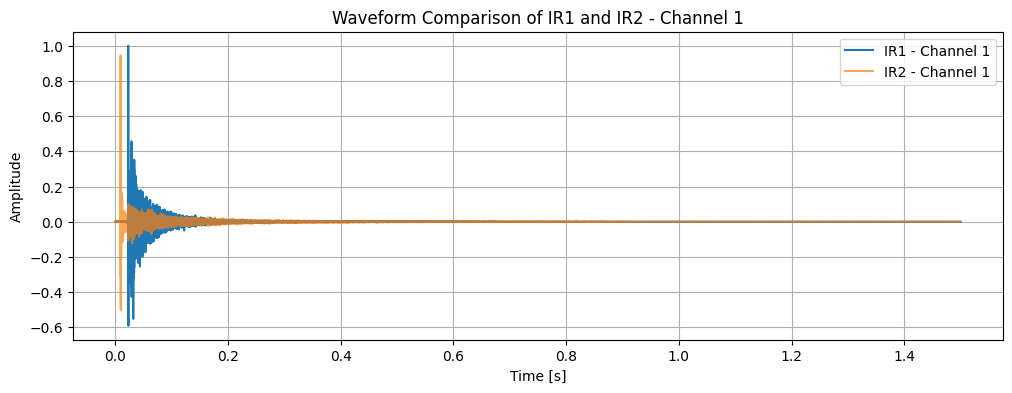

In [10]:
# take first channel of both files

ir1_data, ir1_sr = sf.read(ir1)
ir2_data, ir2_sr = sf.read(ir2)

#cut to 2.5s
ir1_data = ir1_data[:int(1.5*ir1_sr), :]
ir2_data = ir2_data[:int(1.5*ir2_sr), :]

t= np.arange(ir1_data.shape[0]) / ir1_sr
# compare waveform

plt.figure(figsize=(12, 4))
plt.plot(t, ir1_data[:,0], label='IR1 - Channel 1')
plt.plot(t, ir2_data[:,0], label='IR2 - Channel 1', alpha=0.7)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Waveform Comparison of IR1 and IR2 - Channel 1')
plt.legend()
plt.grid()
plt.show()

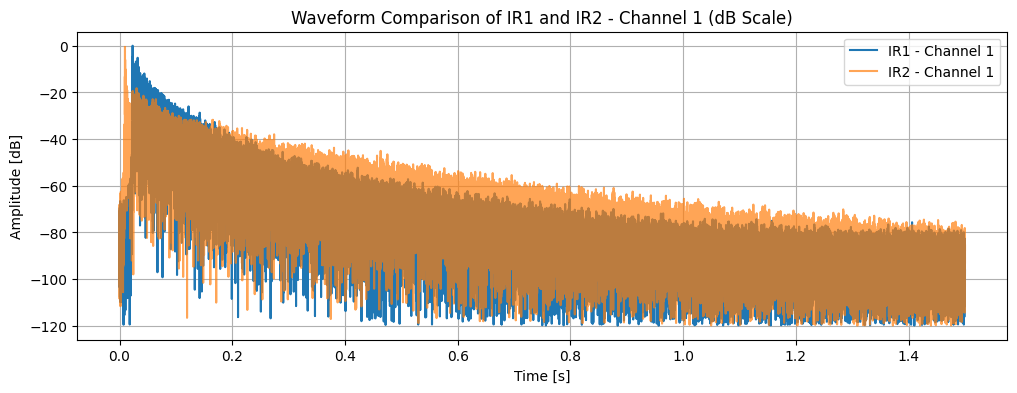

In [11]:
#plot waveform in db

plt.figure(figsize=(12, 4))
plt.plot(t, 20 * np.log10(np.abs(ir1_data[:,0]) + 1e-6), label='IR1 - Channel 1')
plt.plot(t, 20 * np.log10(np.abs(ir2_data[:,0]) + 1e-6), label='IR2 - Channel 1', alpha=0.7)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [dB]')
plt.title('Waveform Comparison of IR1 and IR2 - Channel 1 (dB Scale)')
plt.legend()
plt.grid()
plt.show()  

In [18]:
def normalized_echo_density(ir, wtaps):
    """
    Faithful translation of MATLAB rrecho(ir, wtaps).
    Returns (ned, rep).
    - ir: (N,) or (N,C)
    - wtaps: int window length, or array-like window
    """
    ir = np.asarray(ir, dtype=np.float64)
    if ir.ndim == 1:
        ir = ir[:, None]  # (N,1)

    N, C = ir.shape

    wt = np.asarray(wtaps, dtype=np.float64).ravel()
    if wt.size == 1:
        L = int(wt[0])
        if L < 1:
            raise ValueError("wtaps must be >= 1")
        window = np.hanning(L)
    else:
        window = wt
        L = window.size

    window = window / (window.sum() + 1e-18)
    half = L // 2

    x2 = ir**2  # instantaneous energy

    # rep^2 = windowed mean of x2
    rep2 = np.zeros_like(x2)
    for c in range(C):
        rep2[:, c] = fftconvolve(x2[:, c], window, mode="same")
    rep = np.sqrt(np.maximum(rep2, 0.0))

    # NED: weighted fraction above rep^2, computed in blocks (memory-safe)
    ned = np.zeros_like(x2)
    x2p = np.pad(x2, ((half, half), (0, 0)), mode="constant", constant_values=0.0)

    block = 4096
    for start in range(0, N, block):
        stop = min(N, start + block)
        B = stop - start
        thr = rep2[start:stop, :]  # (B,C)

        acc = np.zeros((B, C), dtype=np.float64)
        for i in range(L):
            seg = x2p[start + i : start + i + B, :]  # (B,C)
            acc += window[i] * (seg > thr)

        ned[start:stop, :] = acc

    ned = ned / erfc(1 / np.sqrt(2))

    if ned.shape[1] == 1:
        return ned[:, 0], rep[:, 0]
    return ned, rep

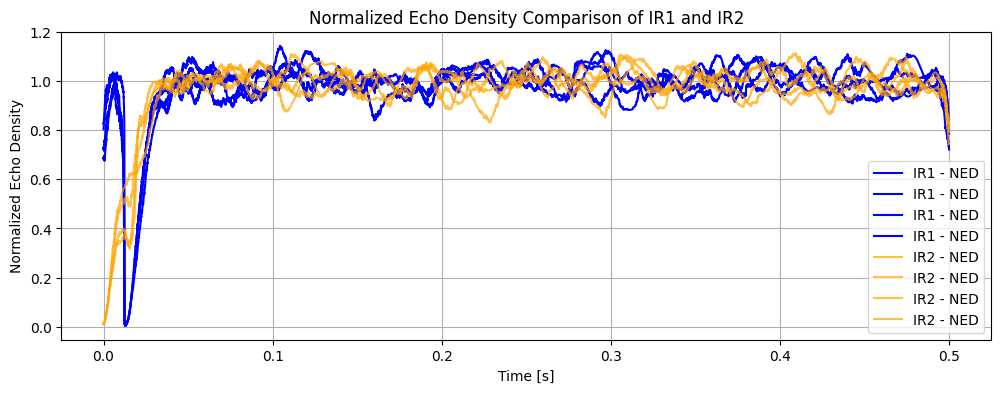

In [22]:
# plot comparison of normalized echo density
ed1, rep1 = normalized_echo_density(ir1_data[:24000], 1048)
ed2, rep2 = normalized_echo_density(ir2_data[:24000], 1048) 

plt.figure(figsize=(12, 4))
plt.plot(t[:24000], ed1, label='IR1 - NED', color='blue') 
plt.plot(t[:24000], ed2, label='IR2 - NED', color='orange', alpha=0.7)
plt.xlabel('Time [s]')
plt.ylabel('Normalized Echo Density')
plt.title('Normalized Echo Density Comparison of IR1 and IR2')
plt.legend()
plt.grid()
plt.show()


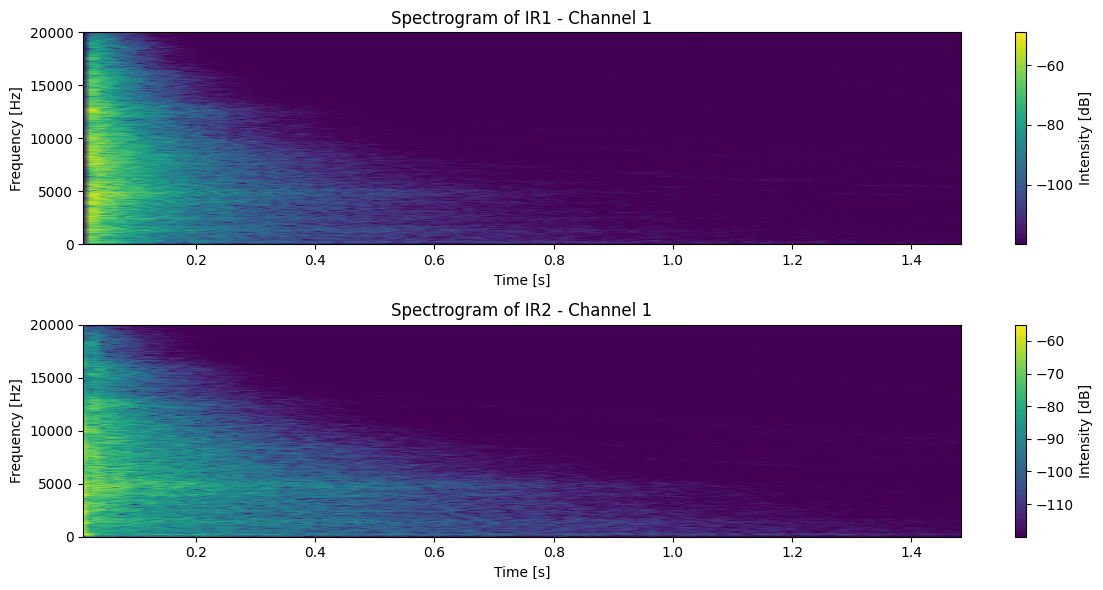

In [25]:
# compare spectrograms
f, t_spec, S1 = signal.spectrogram(ir1_data[:,0], fs=ir1_sr, nperseg=1024, noverlap=512)
f, t_spec, S2 = signal.spectrogram(ir2_data[:,0], fs=ir2_sr, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 6)) 
plt.subplot(2, 1, 1)
plt.pcolormesh(t_spec, f, 10 * np.log10(S1 + 1e-12), shading='gouraud')
plt.colorbar(label='Intensity [dB]')
plt.title('Spectrogram of IR1 - Channel 1')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]') 
plt.ylim(0, 20000)
plt.subplot(2, 1, 2)
plt.pcolormesh(t_spec, f, 10 * np.log10(S2 + 1e-12), shading='gouraud')
plt.colorbar(label='Intensity [dB]')
plt.title('Spectrogram of IR2 - Channel 1')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 20000)
plt.tight_layout()
plt.show()

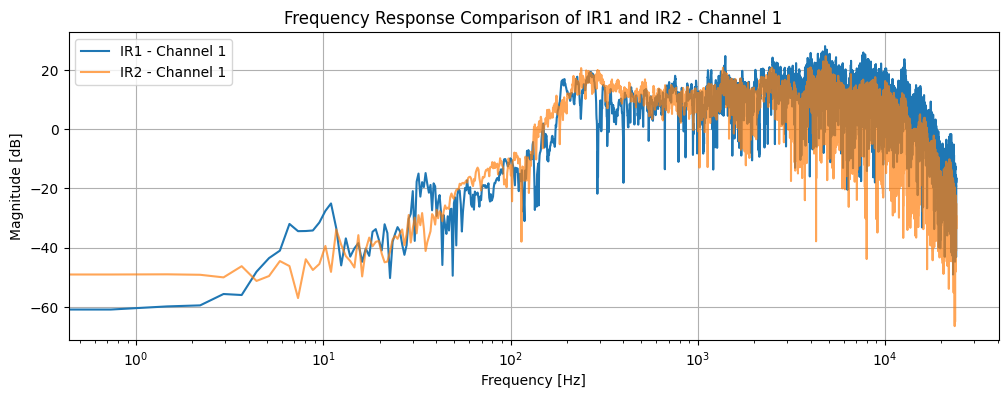

In [ ]:
# plot frequency response ()
IR1_fft = np.fft.rfft(ir1_data[:,0], n=65536)
IR2_fft = np.fft.rfft(ir2_data[:,0], n=65536)
freqs = np.fft.rfftfreq(65536, d=1/ir1_sr)

plt.figure(figsize=(12, 4))
plt.semilogx(freqs, 20 * np.log10(np.abs(IR1_fft) + 1e-12), label='IR1 - Channel 1')
plt.semilogx(freqs, 20 * np.log10(np.abs(IR2_fft) + 1e-12), label='IR2 - Channel 1', alpha=0.7)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Frequency Response Comparison of IR1 and IR2 - Channel 1')
plt.legend()
plt.grid()
plt.show()

In [31]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from typing import Dict, Tuple, List, Optional

def third_octave_centers(fs: float,
                         fmin: float = 20.0,
                         fmax: Optional[float] = None,
                         fref: float = 1000.0) -> np.ndarray:
    """
    Exact 1/3-octave center frequencies: f_c = fref * 2^(k/3).
    Returns centers within [fmin, fmax], with fmax defaulting to 0.95*Nyquist.
    """
    nyq = fs / 2.0
    if fmax is None:
        fmax = 0.95 * nyq

    # Find k range such that fref*2^(k/3) in [fmin, fmax]
    k_min = int(np.ceil(3.0 * np.log2(fmin / fref)))
    k_max = int(np.floor(3.0 * np.log2(fmax / fref)))

    k = np.arange(k_min, k_max + 1)
    fc = fref * (2.0 ** (k / 3.0))
    return fc

def edt_from_edc_db(edc_db: np.ndarray, fs: float,
                    fit_db_low: float = -10.0,
                    fit_db_high: float = 0.0) -> Tuple[float, float]:
    """
    Fit EDC in [fit_db_low, fit_db_high] dB and extrapolate to -60 dB.
    Returns (edt_seconds, slope_db_per_s). NaN if not enough points.
    """
    idx = np.where((edc_db <= fit_db_high) & (edc_db >= fit_db_low))[0]
    if idx.size < 2:
        return np.nan, np.nan

    t = idx / fs
    y = edc_db[idx]
    slope, intercept = np.polyfit(t, y, 1)  # dB = slope*t + intercept
    if slope >= 0:  # non-decaying or pathological
        return np.nan, slope

    edt = -60.0 / slope
    return float(edt), float(slope)

def edt_third_octave(
    ir: np.ndarray,
    fs: float,
    wtaps_ms_skip: float = 0.0,
    fmin: float = 20.0,
    fmax: Optional[float] = None,
    order: int = 6,
    fit_db_low: float = -10.0,
    fit_db_high: float = 0.0,
) -> Dict[float, Dict[str, float]]:
    """
    Compute EDT in 1/3-octave bands.

    Returns a dict keyed by band center frequency (Hz), each with:
      {"edt_s": ..., "slope_db_per_s": ..., "f_lo": ..., "f_hi": ...}
    """
    ir = np.asarray(ir, dtype=np.float64).ravel()
    fs = float(fs)
    nyq = fs / 2.0

    start = int(round(wtaps_ms_skip * 1e-3 * fs))
    if start >= ir.size:
        raise ValueError("wtaps_ms_skip is beyond IR length.")
    h = ir[start:]

    fc_list = third_octave_centers(fs, fmin=fmin, fmax=fmax)

    results: Dict[float, Dict[str, float]] = {}

    for fc in fc_list:
        # 1/3-octave band edges
        f_lo = fc / (2.0 ** (1.0 / 6.0))
        f_hi = fc * (2.0 ** (1.0 / 6.0))

        # Skip bands too close to DC or Nyquist
        if f_lo <= 0.0 or f_hi >= 0.999 * nyq:
            continue

        # Bandpass filter (offline, zero-phase)
        sos = butter(order, [f_lo / nyq, f_hi / nyq], btype="bandpass", output="sos")
        hb = sosfiltfilt(sos, h)

        # Schroeder EDC
        e = hb * hb
        edc = np.cumsum(e[::-1])[::-1]
        if edc[0] <= 0:
            edt, slope = np.nan, np.nan
        else:
            edc_db = 10.0 * np.log10(edc / edc[0])
            edt, slope = edt_from_edc_db(edc_db, fs, fit_db_low=fit_db_low, fit_db_high=fit_db_high)

        results[float(fc)] = {
            "edt_s": float(edt),
            "slope_db_per_s": float(slope),
            "f_lo": float(f_lo),
            "f_hi": float(f_hi),
        }

    return results


AttributeError: 'tuple' object has no attribute 'keys'

<Figure size 800x600 with 0 Axes>